In [40]:
import tensorflow as tf
from tensorflow import keras

In [41]:
from tensorflow.keras.preprocessing.image import load_img

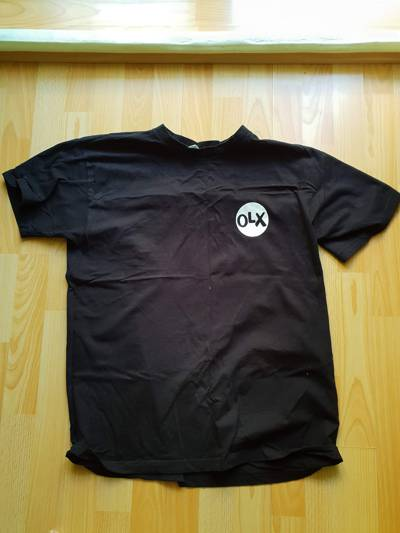

In [42]:
path = '../data/clothing-dataset-small/train/t-shirt'
name = '5f0a3fa0-6a3d-4b68-b213-72766a643de7.jpg'
fullname = f'{path}/{name}'
load_img(fullname)

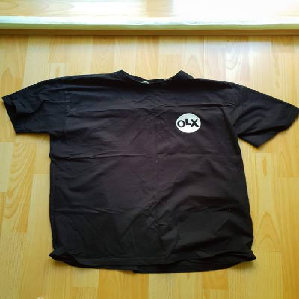

In [43]:
img = load_img(fullname, target_size=(299, 299))
img

In [44]:
import numpy as np
x = np.array(img)
x.shape

(299, 299, 3)

In [45]:
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications.xception import decode_predictions

In [46]:
model = Xception(weights='imagenet', input_shape=(299, 299, 3))

In [47]:
x = np.array(img)
X = np.array([x])
X = preprocess_input(X)

pred = model.predict(X)
decode_predictions(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step


[[('n03595614', 'jersey', np.float32(0.6819633)),
  ('n02916936', 'bulletproof_vest', np.float32(0.03814007)),
  ('n04370456', 'sweatshirt', np.float32(0.034324754)),
  ('n03710637', 'maillot', np.float32(0.011354214)),
  ('n04525038', 'velvet', np.float32(0.0018453592))]]

In [48]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [50]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_ds = train_gen.flow_from_directory(
    '../data/clothing-dataset-small/train',
    target_size=(150, 150),
    batch_size=32
)

Found 3068 images belonging to 10 classes.


In [51]:
X, y = next(train_ds)

In [53]:
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    '../data/clothing-dataset-small/validation',
    target_size=(150, 150),
    batch_size=32,
    shuffle=False
)

Found 341 images belonging to 10 classes.


In [54]:
base_model = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
)

base_model.trainable = False

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step


In [55]:
inputs = keras.Input(shape=(150, 150, 3))

base = base_model(inputs, training=False)

vectors = keras.layers.GlobalAveragePooling2D()(base)

outputs = keras.layers.Dense(10)(vectors)

model = keras.Model(inputs, outputs)

In [56]:
outputs = keras.layers.Dense(10)(vectors)

In [57]:
learning_rate = 0.01
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

In [58]:
loss = keras.losses.CategoricalCrossentropy(from_logits=True)

In [59]:
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

In [60]:
history = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.6802 - loss: 1.2171 - val_accuracy: 0.7595 - val_loss: 0.9694
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 95s 986ms/step - accuracy: 0.8211 - loss: 0.6184 - val_accuracy: 0.7507 - val_loss: 0.9750
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 95s 994ms/step - accuracy: 0.8690 - loss: 0.3958 - val_accuracy: 0.8152 - val_loss: 0.8514
Epoch 4/10
19/96 ━━━━━━━━━━━━━━━━━━━━ 1:17 1s/step - accuracy: 0.9030 - loss: 0.2446

KeyboardInterrupt: 

In [61]:
def make_model(learning_rate=0.01):
    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(150, 150, 3)
    )

    base_model.trainable = False

    #########################################

    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    outputs = keras.layers.Dense(10)(vectors)
    model = keras.Model(inputs, outputs)

    #########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

In [ ]:
scores = {}

for lr in [0.0001, 0.001, 0.01, 0.1]:
    print(lr)

    model = make_model(learning_rate=lr)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[lr] = history.history

    print()